In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Subset

from src.configuracion import *

from src.dataset import XView2
from src.modelos import SiameseResNet18

from src.entrenamiento import (
    crear_dataloaders,
    train_model
)

from src.evaluacion import evaluarM

from src.visualizacion import (
    mostrar_metricas,
    graficar_loss,
    graficar_accuracy,
    graficar_matriz_confusion
)

In [2]:
print(f"Dispositivo: {DEVICE}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")
print(f"Dataset: {DATASET_DIR}")

Dispositivo: cpu
Batch Size: 32
Epochs: 100
Dataset: /home/markusancestro/Documentos/UPIIT-IPN/xView2_Dataset/geotiffs


In [3]:
dataset = XView2(DATASET_DIR)

if SAMPLE_SIZE is not None:
    dataset = Subset(
        dataset,
        range(min(SAMPLE_SIZE, len(dataset)))
    )

print(f"Muestras utilizadas: {len(dataset)}")

Escenas encontradas: 11034
Total edificios: 411357
Muestras utilizadas: 260


In [4]:
train_loader, val_loader, test_loader = crear_dataloaders(dataset)

print(f"Train: {len(train_loader)} batches")
print(f"Val: {len(val_loader)} batches")
print(f"Test: {len(test_loader)} batches")

Train: 6 batches
Val: 2 batches
Test: 2 batches


In [5]:
model = SiameseResNet18().to(DEVICE)

print(model.__class__.__name__)

SiameseResNet18


In [6]:
weights = torch.tensor(
    CLASS_WEIGHTS,
    dtype=torch.float32
).to(DEVICE)

criterion = nn.CrossEntropyLoss(
    weight=weights
)

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

In [8]:
history = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    EPOCHS,
    DEVICE
)

Epoch [1/100] | Train Loss: 1.0210 | Train Acc: 1.0000 | Val Loss: 1.0334 | Val Acc: 1.0000
Epoch [2/100] | Train Loss: 1.0064 | Train Acc: 0.9945 | Val Loss: 1.0097 | Val Acc: 1.0000
Epoch [3/100] | Train Loss: 0.9861 | Train Acc: 0.9945 | Val Loss: 0.9852 | Val Acc: 1.0000
Epoch [4/100] | Train Loss: 0.9735 | Train Acc: 0.9945 | Val Loss: 0.9621 | Val Acc: 1.0000
Epoch [5/100] | Train Loss: 0.9273 | Train Acc: 0.9890 | Val Loss: 0.9392 | Val Acc: 1.0000
Epoch [6/100] | Train Loss: 0.9145 | Train Acc: 0.9890 | Val Loss: 0.9135 | Val Acc: 1.0000
Epoch [7/100] | Train Loss: 0.8595 | Train Acc: 0.9945 | Val Loss: 0.8873 | Val Acc: 1.0000
Epoch [8/100] | Train Loss: 0.8534 | Train Acc: 0.9945 | Val Loss: 0.8641 | Val Acc: 1.0000
Epoch [9/100] | Train Loss: 0.8027 | Train Acc: 0.9945 | Val Loss: 0.8408 | Val Acc: 1.0000
Epoch [10/100] | Train Loss: 0.7761 | Train Acc: 0.9945 | Val Loss: 0.8183 | Val Acc: 1.0000
Epoch [11/100] | Train Loss: 0.7583 | Train Acc: 0.9890 | Val Loss: 0.7906 | Va

In [9]:
modelo_path = MODELOS_DIR / "siamese_resnet18_xview2.pth"
torch.save(model.state_dict(),modelo_path)
print(f"Modelo guardado en:\n{modelo_path}")

Modelo guardado en:
/home/markusancestro/Documentos/UPIIT-IPN/Redes Neuronales/Proyecto_Clasificador_De_Daño_Imagenes_Satelitales/modelos/siamese_resnet18_xview2.pth


Accuracy : 0.9487
Precision: 0.9001
Recall   : 0.9487
F1 Score : 0.9238
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        37
           1       0.00      0.00      0.00         2

    accuracy                           0.95        39
   macro avg       0.47      0.50      0.49        39
weighted avg       0.90      0.95      0.92        39



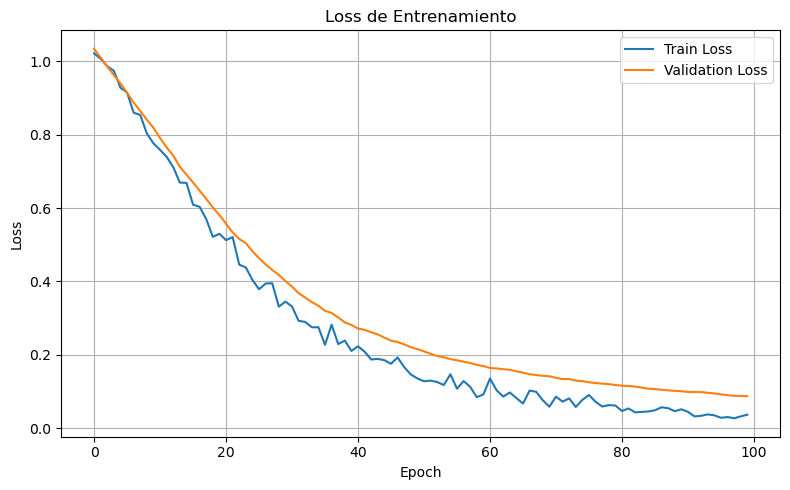

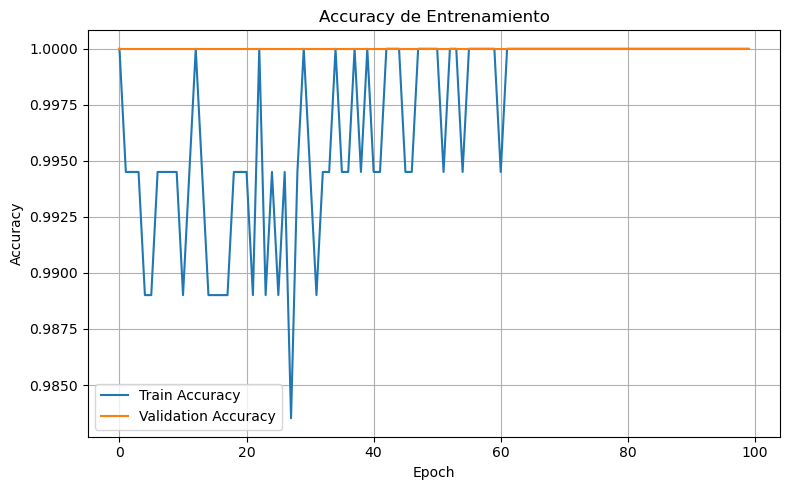

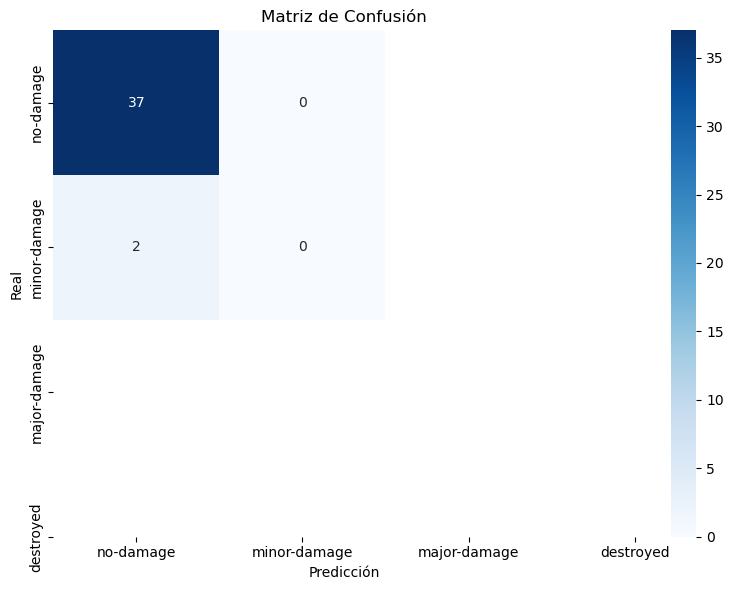

In [10]:
resultados = evaluarM(model,test_loader,DEVICE)
mostrar_metricas(resultados)
print(resultados["report"])
graficar_loss(history)
graficar_accuracy(history)
graficar_matriz_confusion(resultados["confusion_matrix"],list(CLASSES.keys()))
